# Clasificación de datos
En el presente archivo, se muestra el entrenamiento de los clasificadores de datos del laboratorio 2 del módulo tres del curso 1MTR53 de la PUCP

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Lectura y preparación de datos
Para una mayor facilidad, se juntan los datos en una lista. El label subject_id se añade para hacer la diferenciación de datos.

In [2]:
DATA_DIR = Path("data")

SUBJECTS = [f"S{i}" for i in range(1, 8)]

features_list = []

for subject in SUBJECTS:

    file_path = DATA_DIR / f"{subject}_features.csv"

    if not file_path.exists():
        print(f"No encontrado: {file_path}")
        continue

    df = pd.read_csv(file_path)

    # Asegurar que el subject_id sea correcto
    df["subject_id"] = subject

    print(f"{subject}: {df.shape[0]} muestras")

    features_list.append(df)


# Unir todos los sujetos
features_all = pd.concat(
    features_list,
    ignore_index=True
)

print("\n==============================")
print("DATASET COMPLETO")
print("==============================")

print("Tamaño:", features_all.shape)

print("\nSujetos:")
print(features_all["subject_id"].value_counts().sort_index())



S1: 1246 muestras
S2: 1242 muestras
S3: 1244 muestras
S4: 1216 muestras
S5: 1239 muestras
S6: 1328 muestras
S7: 1250 muestras

DATASET COMPLETO
Tamaño: (8765, 20)

Sujetos:
subject_id
S1    1246
S2    1242
S3    1244
S4    1216
S5    1239
S6    1328
S7    1250
Name: count, dtype: int64


## Definición de características

In [3]:
feature_cols = [
    "EOGh_mean",
    "EOGh_mav",
    "EOGh_rms",
    "EOGh_std",
    "EOGh_max",
    "EOGh_min",
    "EOGh_ptp",
    "EOGh_wl",

    "EOGv_mean",
    "EOGv_mav",
    "EOGv_rms",
    "EOGv_std",
    "EOGv_max",
    "EOGv_min",
    "EOGv_ptp",
    "EOGv_wl"
]


X = features_all[feature_cols]
y = features_all["label"]

## Entrenamiento
Se decide separar los datos correspondientes en train y test. El sujeto 7 será reservado para los datos de testeo.

Se entrenarán 2 modelos
- Random Forest
- Super Vector Machine (SVM)

In [4]:
TEST_SUBJECT = "S7"  # Sujeto reservado para prueba

train_df = features_all[
    features_all["subject_id"] != TEST_SUBJECT
].copy()

test_df = features_all[
    features_all["subject_id"] == TEST_SUBJECT
].copy()


# Datos de entrenamiento
X_train = train_df[feature_cols]
y_train = train_df["label"]


# Datos de prueba
X_test = test_df[feature_cols]
y_test = test_df["label"]


print("\n==============================")
print("CONJUNTO DE ENTRENAMIENTO")
print("==============================")

print("Sujetos:", sorted(train_df["subject_id"].unique()))
print("Número de muestras:", len(train_df))


print("\n==============================")
print("CONJUNTO DE PRUEBA (SUJETO RESERVADO)")
print("==============================")

print("Sujeto:", TEST_SUBJECT)
print("Número de muestras:", len(test_df))

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


CONJUNTO DE ENTRENAMIENTO
Sujetos: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6']
Número de muestras: 7515

CONJUNTO DE PRUEBA (SUJETO RESERVADO)
Sujeto: S7
Número de muestras: 1250


In [5]:
RANDOM_STATE = 42
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=5,
        random_state=RANDOM_STATE
    ),
    "Support Vector Machine (SVM)": SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        random_state=RANDOM_STATE
    ),
}

fitted_models = {}
results = []

for name, model in models.items():
    # Entrenamiento
    model.fit(X_train_scaled, y_train)
    fitted_models[name] = model

    # Predicción en el sujeto de prueba
    y_pred = model.predict(X_test_scaled)

    # Métricas de evaluación
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "Modelo": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4)
    })

## Resultados

In [6]:
df_results = pd.DataFrame(results)

print("=" * 60)
print(f"SUJETO RESERVADO PARA PRUEBA: {TEST_SUBJECT}")
print("Sujetos de entrenamiento:", sorted(train_df["subject_id"].unique()))
print("=" * 60)
print("\n--- TABLA COMPARATIVA DE MODELOS ---")
print(df_results.to_string(index=False))
print("=" * 60)

SUJETO RESERVADO PARA PRUEBA: S7
Sujetos de entrenamiento: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6']

--- TABLA COMPARATIVA DE MODELOS ---
                      Modelo  Accuracy  Precision  Recall  F1-Score
               Random Forest    0.8856     0.8941  0.8856    0.8876
Support Vector Machine (SVM)    0.9112     0.9123  0.9112    0.9093


## Evaluación final del mejor modelo
Seleccionamos finalmente el mejor modelo en base al F1-score

In [7]:
best_row = df_results.loc[df_results["F1-Score"].idxmax()]
best_model_name = best_row["Modelo"]
best_model = fitted_models[best_model_name]

print(f"Modelo seleccionado: {best_model_name}")
print(best_row.to_string())

Modelo seleccionado: Support Vector Machine (SVM)
Modelo       Support Vector Machine (SVM)
Accuracy                           0.9112
Precision                          0.9123
Recall                             0.9112
F1-Score                           0.9093



RESULTADOS FINALES - Support Vector Machine (SVM)
Accuracy:  0.9112
Precision: 0.9123
Recall:    0.9112
F1-Score:  0.9093

Reporte de clasificación:
              precision    recall  f1-score   support

           1       0.97      0.80      0.88       246
           2       0.86      0.80      0.83       245
           3       0.91      0.98      0.95       759

    accuracy                           0.91      1250
   macro avg       0.91      0.86      0.88      1250
weighted avg       0.91      0.91      0.91      1250


Matriz de confusión:
[[197  22  27]
 [  4 197  44]
 [  3  11 745]]


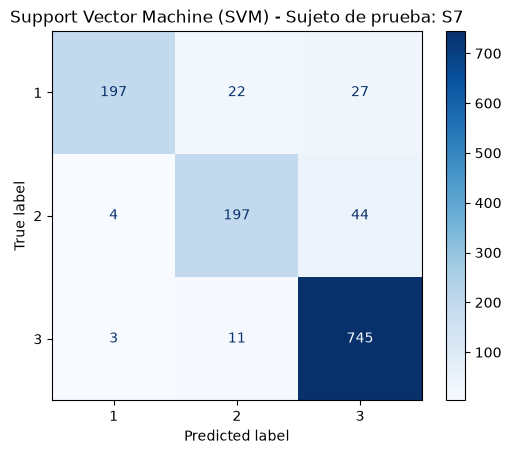

In [8]:
y_pred_best = best_model.predict(X_test_scaled)

final_accuracy = accuracy_score(y_test, y_pred_best)
final_precision = precision_score(y_test, y_pred_best, average="weighted")
final_recall = recall_score(y_test, y_pred_best, average="weighted")
final_f1 = f1_score(y_test, y_pred_best, average="weighted")

print("\n==============================")
print(f"RESULTADOS FINALES - {best_model_name}")
print("==============================")
print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-Score:  {final_f1:.4f}")

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_best))

labels_sorted = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred_best, labels=labels_sorted)

print("\nMatriz de confusión:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels_sorted
)

disp.plot(cmap="Blues")
plt.title(f"{best_model_name} - Sujeto de prueba: {TEST_SUBJECT}")
plt.show()

## Exportar modelo

In [ ]:
final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", type(best_model)(**best_model.get_params()))
])

# Se reentrena el pipeline completo (escalador + modelo) con los datos de entrenamiento
final_pipeline.fit(X_train, y_train)

output_path = Path("SVM_Model.joblib")
joblib.dump(final_pipeline, output_path)

print(f"Modelo '{best_model_name}' (con preprocesamiento incluido) exportado en: {output_path.resolve()}")

# Verificación rápida: el pipeline exportado debe reproducir las mismas métricas
y_pred_pipeline = final_pipeline.predict(X_test)
print("Accuracy del pipeline exportado sobre el sujeto de prueba:",
      round(accuracy_score(y_test, y_pred_pipeline), 4))

Modelo 'Support Vector Machine (SVM)' (con preprocesamiento incluido) exportado en: C:\Users\Nicolas Vega\OneDrive\Documentos\PUCP\9 CICLO\FUNBIO\1MTR58_FUNBIO\M3_Lab2\best_model_pipeline.joblib
Accuracy del pipeline exportado sobre el sujeto de prueba: 0.9112
